Plot for Deliverable 1

In [32]:
import xarray as xr
import numpy as np
import pandas as pd

variables = ["tas","precip","evap","soiltemp","sm","snowdepth","LAI_PFT","windspeed","iceconc","ice_sheet"]
var_names = ["temp","precip","evap","soil temp","soil moist","snow depth","LAI_PFT","wind speed","sea ice","ice sheet"]
units = ["°C", "mm/month", "mm/month", "°C", "kg/m²", "kg/m²", " ", "m/s", "%", " "]  # Units for each variable
longnames = [
    "2m Air Temperature",
    "Surface Precipitation",
    "Evapotranspiration",
    "Soil Temperature from top layer",
    "Soil Moisture from top layer",
    "Snow Depth",
    "Leaf Area Index (LAI)",
    "10m Wind Speed",
    "Sea Ice Concentration",
    "Ice Sheet 0/1"
 ]  # Long names for each variable
scenarios=["natural","SSP126","SSP245","SSP370","SSP585","10000PGC"]

site = "_LA"
downscaled = False  # Set to True if downscaled data is used, False otherwise
var = 5
scen = None  # Not used when looping all scenarios

In [33]:
data_path = "site_data/"

def load_site_series(scenario):
    if downscaled:
        data_file = f"downscaled/{variables[var]}_{scenario}_site{site}_downscaled.txt"
    else:
        if variables[var] in ["iceconc"]:
            data_file = f"site{site}/{variables[var]}_{scenario}_site{site}.txt"
        else:
            data_file = f"site{site}/{variables[var]}_{scenario}_site{site}.txt"

    print("Loading data from:", data_file)
    data = np.loadtxt(data_path + data_file)
    print("shape of data:", data.shape)
    # Each row is an ensemble member, each column is a time step (AP kyr).
    return data


In [34]:
print("first few values for each scenario is:")
for scen in scenarios:
    data = load_site_series(scen)
    tmp = data[:,:10]
    print(f"Scenario: {scen}, first few values:\n", tmp.max())

first few values for each scenario is:
Loading data from: site_LA/snowdepth_natural_site_LA.txt
shape of data: (90, 1001)
Scenario: natural, first few values:
 2.169253
Loading data from: site_LA/snowdepth_SSP126_site_LA.txt
shape of data: (90, 1001)
Scenario: SSP126, first few values:
 0.390256
Loading data from: site_LA/snowdepth_SSP245_site_LA.txt
shape of data: (90, 1001)
Scenario: SSP245, first few values:
 0.404351
Loading data from: site_LA/snowdepth_SSP370_site_LA.txt
shape of data: (90, 1001)
Scenario: SSP370, first few values:
 0.530615
Loading data from: site_LA/snowdepth_SSP585_site_LA.txt
shape of data: (90, 1001)
Scenario: SSP585, first few values:
 0.253113
Loading data from: site_LA/snowdepth_10000PGC_site_LA.txt
shape of data: (90, 1001)
Scenario: 10000PGC, first few values:
 0.215948


Loading data from: site_LA/snowdepth_natural_site_LA.txt
shape of data: (90, 1001)
Loading data from: site_LA/snowdepth_SSP126_site_LA.txt
shape of data: (90, 1001)
Loading data from: site_LA/snowdepth_SSP245_site_LA.txt
shape of data: (90, 1001)
Loading data from: site_LA/snowdepth_SSP370_site_LA.txt
shape of data: (90, 1001)
Loading data from: site_LA/snowdepth_SSP585_site_LA.txt
shape of data: (90, 1001)
Loading data from: site_LA/snowdepth_10000PGC_site_LA.txt
shape of data: (90, 1001)


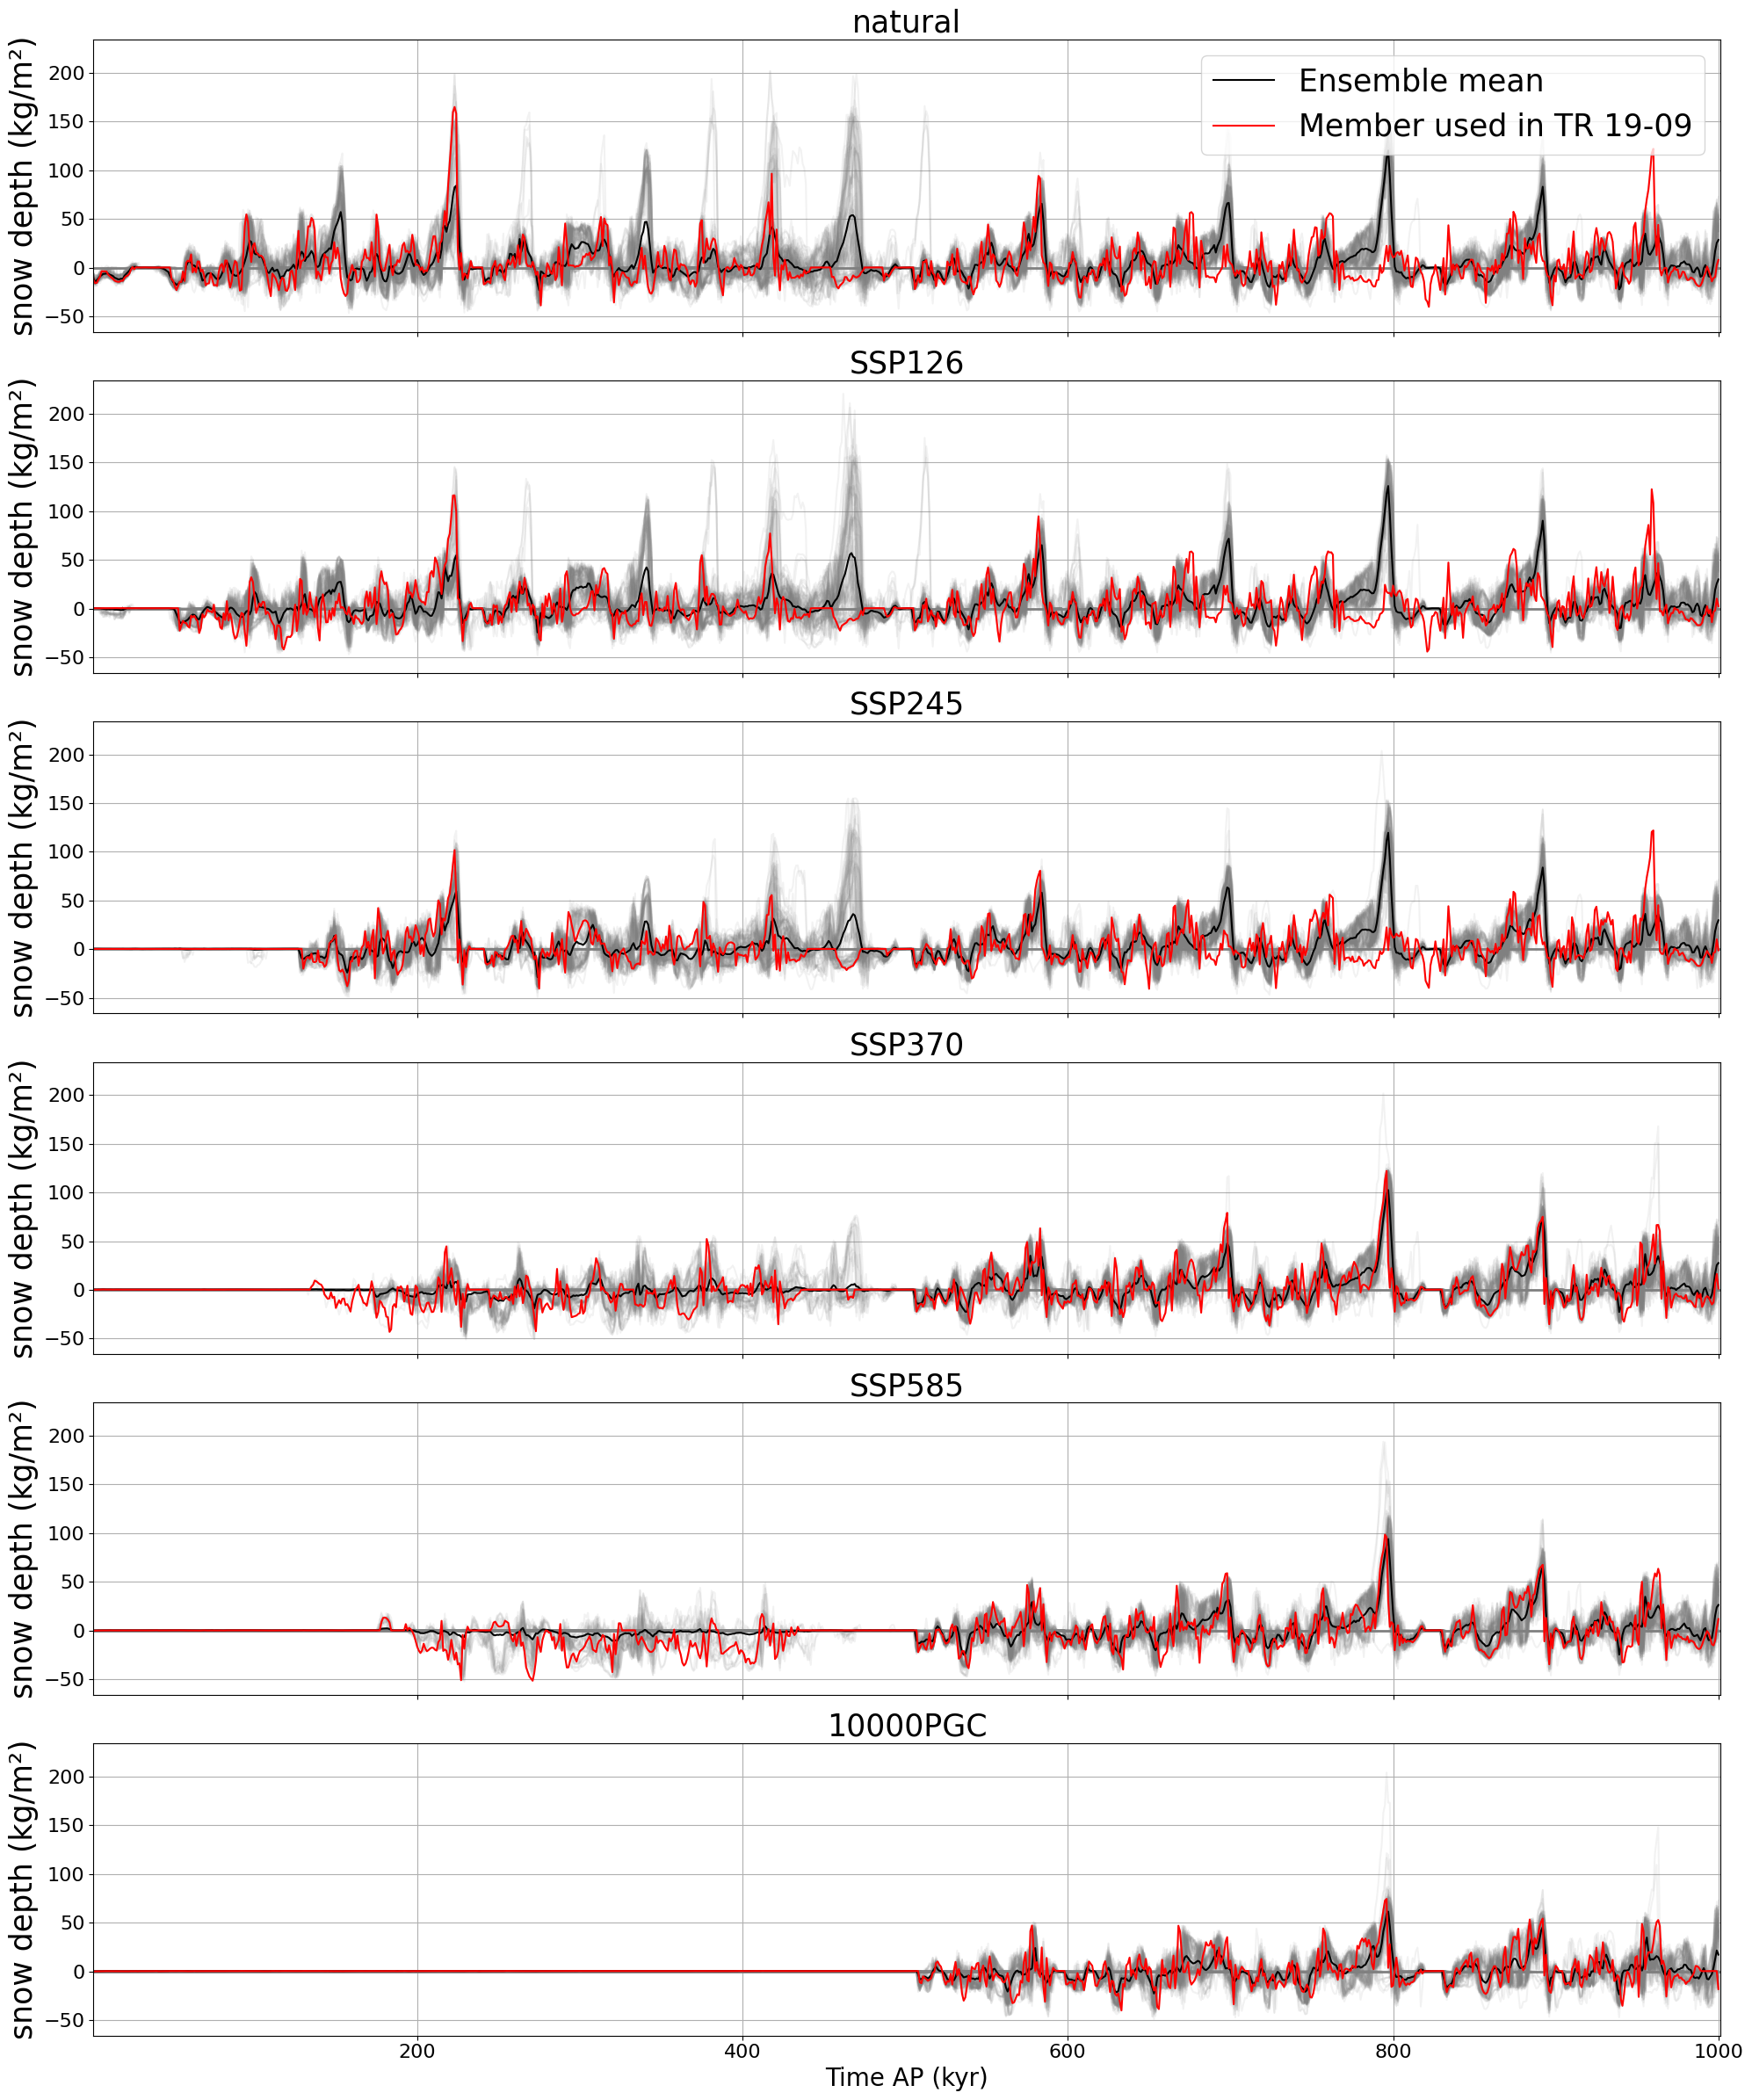

In [35]:
import matplotlib.pyplot as plt

scenarios=["natural","SSP126","SSP245","SSP370","SSP585","10000PGC"]

# Preload data to compute a shared y-limit
data_by_scen = []
global_min = np.inf
global_max = -np.inf
for scenario in scenarios:
    data = load_site_series(scenario)
    data_by_scen.append(data)
    global_min = min(global_min, data.min())
    global_max = max(global_max, data.max())
margin = 0.05 * (global_max - global_min)
ymin = global_min - margin
ymax = global_max + margin

n_scen = len(scenarios)
fig, axes = plt.subplots(n_scen, 1, figsize=(20, 4 * n_scen), sharex=True)
if n_scen == 1:
    axes = [axes]

for i_scen, scenario in enumerate(scenarios):
    data = data_by_scen[i_scen]
    ax = axes[i_scen]
    ax.axhline(0, color='grey', linewidth=2)
    for i in range(data.shape[0]):
        ax.plot(data[i, :], color='grey', alpha=0.1)
    ax.plot(data.mean(axis=0), color='black', label='Ensemble mean')
    if data.shape[0] > 66:
        ax.plot(data[66, :], color='red', label='Member used in TR 19-09')
    ax.set_ylim(ymin, ymax)
    ax.grid()
    ax.set_xlim(1, 1001)
    ax.tick_params(axis='both', labelsize=16)
    if scenario == "natural":
        ax.legend(fontsize=25, loc='upper right')
    ax.set_ylabel(f'{var_names[var]} ({units[var]})', fontsize=25)
    ax.set_title(f'{scenario}', fontsize=25)
    # ax.figure.savefig(f'plots/{variables[var]}_site{site}_{scenario}.png', dpi=300)

axes[-1].set_xlabel('Time AP (kyr)', fontsize=20)
plt.tight_layout()
plt.savefig(f'plots/{variables[var]}_site{site}.png', dpi=300)
plt.show()


